In [1]:
#Import Libraries
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier  
from sklearn.model_selection import train_test_split  
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)  
from imblearn.over_sampling import SMOTE  
import joblib  

plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

In [2]:
# Load the preprocessed splits saved by Notebook 01
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print()
print('Class Distribution in Training Set:')
print(y_train.value_counts().rename({0: 'Not Popular (0)', 1: 'Popular (1)'}))
print()
print('Class Distribution in Test Set:')
print(y_test.value_counts().rename({0: 'Not Popular (0)', 1: 'Popular (1)'}))

X_train shape : (31715, 58)
X_test  shape : (7929, 58)
y_train shape : (31715,)
y_test  shape : (7929,)

Class Distribution in Training Set:
popularity
Popular (1)        16923
Not Popular (0)    14792
Name: count, dtype: int64

Class Distribution in Test Set:
popularity
Popular (1)        4231
Not Popular (0)    3698
Name: count, dtype: int64


### Baseline Random Forest Model

In [3]:
# Train the baseline Random Forest Classifier
# n_estimators=200: 200 decision trees in the ensemble
# max_depth=10: limits tree depth to reduce overfitting
# min_samples_split=5: a node must have at least 5 samples to split
# min_samples_leaf=2: each leaf must have at least 2 samples
# class_weight="balanced": adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all available CPU cores for faster training
)
rf_model.fit(X_train, y_train)  # Train on the training set

# Predictions on the test set
y_pred = rf_model.predict(X_test)          # Predicted class labels
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for class 1

print("Random Forest model trained successfully!")
print(f"Number of Trees : 200")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples    : {X_test.shape[0]}")
print(f"Features Used   : {X_train.shape[1]}")

Random Forest model trained successfully!
Number of Trees : 200
Training Samples: 31715
Test Samples    : 7929
Features Used   : 58


##Model Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC

In [4]:
# Calculate evaluation metrics for the baseline model
# Accuracy  : overall proportion of correct predictions
# Precision : of all predicted positives, how many are truly positive
# Recall    : of all actual positives, how many were correctly identified
# F1-Score  : harmonic mean of precision and recall (useful for imbalanced data)
# ROC-AUC   : area under the ROC curve — measures discriminability
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)

print("===== Random Forest — Model Evaluation =====")
print(f"Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

===== Random Forest — Model Evaluation =====
Accuracy  : 0.6638  (66.38%)
Precision : 0.6864
Recall    : 0.6809
F1-Score  : 0.6837
ROC-AUC   : 0.7230


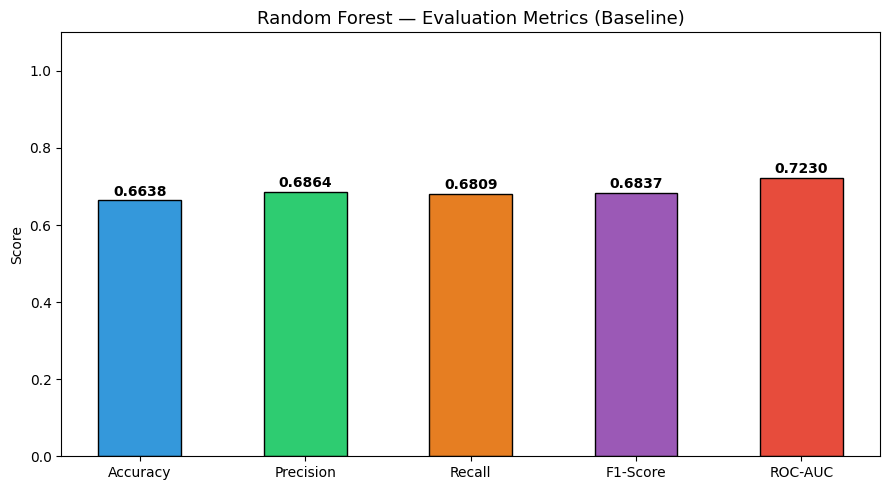

In [5]:
# Bar chart visualization of all evaluation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
values  = [acc, prec, rec, f1, roc]
colors  = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c"]

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 1.1)
plt.title("Random Forest — Evaluation Metrics (Baseline)", fontsize=13)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

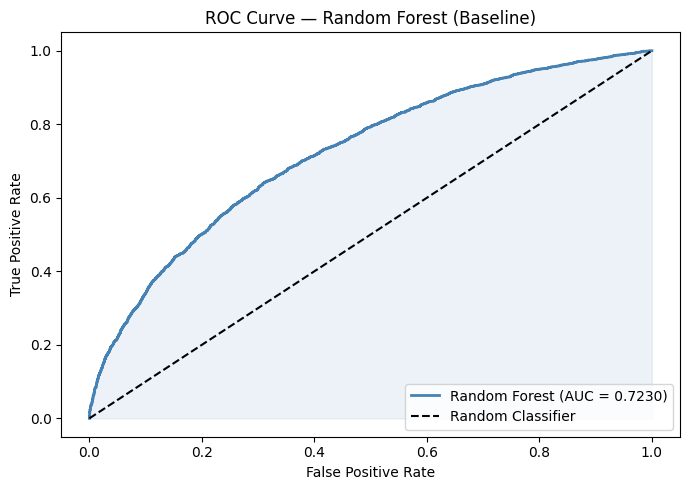

In [6]:
# ROC Curve — plots True Positive Rate vs False Positive Rate at various thresholds
# A random classifier would follow the diagonal; the further the curve is from the
# diagonal, the better the model discriminates between the two classes.
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2,
         label=f"Random Forest (AUC = {roc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest (Baseline)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##Classification Report